# Factor Analysis/PCA for Question 5

### 1. Set up

In [29]:
# import Python packages
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt

# regression package
import statsmodels.api as sm

# PCA / factor analysis
from sklearn.decomposition import PCA

# clustering packages
from sklearn import cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [30]:
# --- factor analysis with scikit-learn ------------------------------------
# loadings, a varimax rotation, and factor scores.

def varimax(loadings,tol=1e-5,max_iter=500):
  '''Varimax rotation with Kaiser normalization (the standard rule)'''
  L = np.asarray(loadings,dtype=float).copy()
  n_rows,n_cols = L.shape
  if n_cols < 2:
    return L
  h = np.sqrt((L**2).sum(axis=1))          # Kaiser: scale each row to unit length
  L = L/h[:,None]
  R,d = np.eye(n_cols),0.0
  for _ in range(max_iter):
    d_old = d
    basis = L @ R
    diag  = np.diag((basis**2).sum(axis=0))
    U,S,Vt = np.linalg.svd(L.T @ (basis**3 - basis @ diag/n_rows))
    R,d = U @ Vt, S.sum()
    if d < d_old*(1+tol):
      break
  return (L @ R)*h[:,None]                 # undo the Kaiser scaling

def run_pca(X,n_factors,rotate=False):
  '''Standardize X, run PCA, and return the factor loadings'''
  Z = preprocessing.scale(X)               # PCA on the correlation matrix
  pca = PCA(n_components=n_factors).fit(Z)
  # sklearn reports variances with the (n-1) convention; rescale to get the
  # eigenvalues of the correlation matrix
  eigenvalues = pca.explained_variance_*(len(Z)-1)/len(Z)
  loadings = pca.components_.T*np.sqrt(eigenvalues)   # eigenvector x sqrt(eigenvalue)
  if rotate:
    loadings = varimax(loadings)
  signs = np.sign(loadings.sum(axis=0)); signs[signs==0] = 1
  return loadings*signs                    # orient each factor positively

def factor_scores(X,loadings):
  '''Translate the original data into factor scores (already standardized)'''
  Z = preprocessing.scale(X)
  return Z @ np.linalg.solve(np.corrcoef(Z,rowvar=False),loadings)

### 2. Import Ford Ka Data

In [31]:
# read in the data
import os
if not os.path.exists('Ford Ka Data.xlsx'):
    from google.colab import files
    uploaded = files.upload()

FILE_PATH = "Ford Ka Data.xlsx"
SHEET_NAME = "Psychographic Data"

df = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME,
    header=6
)

df.head(5)

,Respondent Number,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q53,Q54,Q55,Q56,Q57,Q58,Q59,Q60,Q61,Q62
0,1,6,2,4,3,1,5,5,3,4,...,2,4,5,4,5,3,4,4,4,2
1,2,7,7,7,5,4,4,5,4,5,...,1,1,1,1,5,4,3,5,4,5
2,3,5,4,6,5,7,5,3,5,4,...,3,5,6,3,4,4,5,3,4,4
3,4,4,2,5,4,2,4,5,4,3,...,3,5,4,4,4,2,5,5,5,3
4,5,5,5,7,6,7,3,4,5,4,...,6,4,5,5,4,5,4,3,4,5


In [32]:
# scale the data

scaler = preprocessing.StandardScaler()
df_sc = scaler.fit_transform(df)

df_sc

array([[-1.72513641,  0.58659625, -1.05009144, ...,  0.16593271,
         0.24795029, -1.28828394],
       [-1.71127989,  1.23836986,  1.49867419, ...,  0.89370777,
         0.24795029,  1.02323031],
       [-1.69742337, -0.06517736, -0.03058519, ..., -0.56184234,
         0.24795029,  0.25272556],
       ...,
       [ 1.69742337,  0.58659625,  0.47916794, ..., -2.01739245,
        -1.30173903, -1.28828394],
       [ 1.71127989, -1.36872458, -0.54033831, ...,  0.89370777,
         1.02279495, -0.51777919],
       [ 1.72513641,  1.23836986,  0.98892106, ...,  0.89370777,
        -0.52689437,  1.79373506]])

### 3. PCA Analysis

#### 3.1. PCA - No Rotation

In [33]:
df_loadings = run_pca(df_sc,n_factors=8)

def get_loadings_communalities(loadings,index_names=None,rotated=False,round_dig=3):
  '''Returns a DataFrame containing the loadings and communalities'''
  L = np.asarray(loadings)
  prefix = 'RC' if rotated else 'PC'       # RC = rotated component, PC = principal component
  df = pd.DataFrame(L,
      index=index_names if index_names is not None else [f'q{i}' for i in range(1,1+L.shape[0])],
      columns=[f'{prefix}{i}' for i in range(1,1+L.shape[1])])
  df['communalities'] = (L**2).sum(axis=1)
  return df.round(round_dig)

get_loadings_communalities(df_loadings)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,communalities
q1,-0.064,-0.096,0.030,-0.429,-0.528,-0.263,-0.161,-0.122,0.587
q2,-0.545,-0.216,0.569,0.104,-0.020,-0.016,0.008,-0.041,0.681
q3,-0.853,0.152,0.288,-0.003,0.002,0.021,0.052,0.006,0.837
q4,0.176,0.660,-0.174,0.031,0.015,0.110,0.047,-0.026,0.513
q5,-0.060,0.617,-0.569,-0.075,0.073,-0.005,0.050,-0.077,0.728
...,...,...,...,...,...,...,...,...,...
q59,0.234,-0.101,0.626,0.043,0.175,0.095,-0.003,-0.064,0.502
q60,0.208,-0.210,0.609,0.021,0.104,-0.084,0.140,0.043,0.497
q61,-0.252,0.038,-0.648,0.086,-0.005,-0.025,0.075,0.119,0.513
q62,-0.401,0.131,-0.600,0.007,-0.042,0.081,-0.012,-0.156,0.570


In [34]:

def get_summary(loadings,rotated=False,round_dig=2):
  ''' Print a summary of the PCA fit '''
  L = np.asarray(loadings)
  prefix = 'RC' if rotated else 'PC'
  ss = (L**2).sum(axis=0)
  n_vars = L.shape[0]
  return pd.DataFrame([ss,ss/n_vars,np.cumsum(ss)/n_vars],
      columns=[f'{prefix}{i}' for i in range(1,1+L.shape[1])],
      index=['Sum of Squared Loadings','Proportion of Variance Explained',
             'Cumulative Proportion']).round(round_dig)

get_summary(df_loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Sum of Squared Loadings,16.61,10.79,5.79,1.52,1.30,1.27,1.20,1.16
Proportion of Variance Explained,0.26,0.17,0.09,0.02,0.02,0.02,0.02,0.02
Cumulative Proportion,0.26,0.43,0.53,0.55,0.57,0.59,0.61,0.63


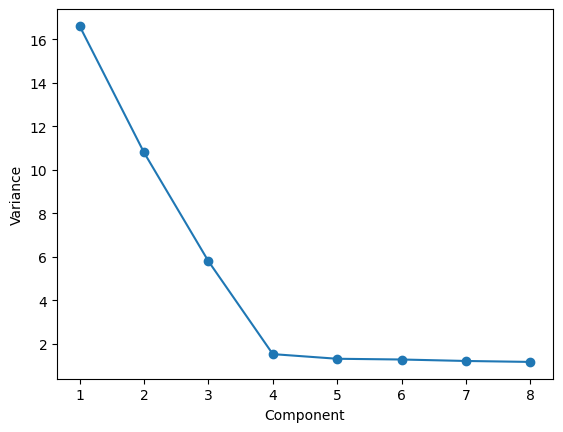

In [35]:
# scree plot - shows successive proportion of additional variance that each component adds
eigenvalues = (df_loadings**2).sum(axis=0)
plt.plot(1+np.arange(len(eigenvalues)),eigenvalues,'o-')
plt.xlabel('Component')
plt.ylabel('Variance')
plt.show()

#### 3.2. PCA-Varimax Rotation

In [36]:
df_loadings_rotated = run_pca(df_sc, n_factors=8, rotate=True)

get_loadings_communalities(df_loadings_rotated,rotated=True)

,RC1,RC2,RC3,RC4,RC5,RC6,RC7,RC8,communalities
q1,0.047,-0.084,-0.029,-0.372,0.069,-0.001,-0.319,-0.576,0.587
q2,0.641,-0.292,0.415,0.088,0.013,0.017,0.006,-0.065,0.681
q3,0.905,0.063,0.072,0.005,0.020,0.062,0.059,-0.031,0.837
q4,-0.151,0.677,-0.110,0.078,-0.001,0.100,0.037,0.056,0.513
q5,-0.019,0.645,-0.545,-0.005,-0.076,-0.042,0.081,0.013,0.728
...,...,...,...,...,...,...,...,...,...
q59,-0.086,-0.116,0.661,0.048,-0.149,0.086,0.081,0.080,0.502
q60,-0.075,-0.222,0.640,-0.045,0.038,-0.037,0.166,0.012,0.497
q61,0.096,0.048,-0.675,0.055,0.143,-0.100,0.041,0.101,0.513
q62,0.253,0.131,-0.679,0.123,-0.089,0.015,-0.012,-0.072,0.570


In [39]:
df_scores = factor_scores(df_sc, df_loadings_rotated)
df_scores = pd.DataFrame(df_scores,columns=['RC1','RC2','RC3','RC4','RC5','RC6','RC7','RC8'])
df_scores.head(5)

,RC1,RC2,RC3,RC4,RC5,RC6,RC7,RC8
0,-0.973093,-1.115609,-0.691863,1.332952,0.493780,0.328398,-0.034673,0.144428
1,1.607343,0.003732,-0.389254,1.405538,0.120771,-0.081261,-0.165442,1.647937
2,-0.375244,1.809562,0.238671,2.053903,-0.563907,0.887022,1.143037,0.861129
3,-1.039918,-0.832130,-1.203858,1.197195,1.549398,0.232312,0.326023,1.475914
4,-0.577455,1.719563,0.033880,-0.401721,-0.161912,-0.533326,1.271720,1.013459


### 4. Cluster Analysis - K-Means

In [41]:
# 1. Function for checking clusters
def check_clusters(data, labels):
    print("Cluster sizes:", pd.Series(labels).value_counts().sort_index().to_dict())

    return pd.pivot_table(
        data,
        index=labels,
        aggfunc='mean'
    )

# 2. Compare different K
for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=1990,
        n_init=10
    )

    labels = kmeans.fit_predict(df_scores)
    score = silhouette_score(df_scores, labels)
    print(f"K={k}, silhouette={score:.3f}")

# 3. Choose a K
kmeans = KMeans(
    n_clusters=4,
    random_state=1990,
    n_init=10
)

labels = kmeans.fit_predict(df_scores)
check_clusters(df_scores, labels)

K=2, silhouette=0.127
K=3, silhouette=0.186
K=4, silhouette=0.240
K=5, silhouette=0.206
K=6, silhouette=0.193
Cluster sizes: {0: 32, 1: 78, 2: 65, 3: 75}


,RC1,RC2,RC3,RC4,RC5,RC6,RC7,RC8
0,-0.450354,-0.547364,2.402383,-0.042150,0.048930,0.144529,0.013132,-0.082305
1,1.401313,-0.370331,-0.239772,0.000583,0.012217,0.002599,0.041837,-0.013263
2,-0.274118,1.631660,-0.068667,0.001492,0.008224,0.063038,-0.044249,0.005165
3,-1.027646,-0.795419,-0.716143,0.016085,-0.040710,-0.119002,-0.010764,0.044433
